<a href="https://colab.research.google.com/github/Amoyeola/PCDP-Team/blob/main/PCDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 2000

vessel_arrival_rate = np.random.randint(15, 60, n_samples)
berth_capacity = np.random.randint(20, 45, n_samples)
yard_occupancy_rate = np.random.uniform(40, 95, n_samples)
truck_turnaround_time = np.random.uniform(0.5, 5, n_samples)
weather_severity_index = np.random.uniform(0, 10, n_samples)

capacity_pressure = np.maximum(vessel_arrival_rate - berth_capacity, 0)

delay_hours = (
    capacity_pressure * 1.5 +
    (yard_occupancy_rate / 100) * 8 +
    truck_turnaround_time * 2 +
    weather_severity_index * 1.2 +
    np.random.normal(0, 2, n_samples)
)

delay_hours = np.maximum(delay_hours, 0)

df = pd.DataFrame({
    "vessel_arrival_rate": vessel_arrival_rate,
    "berth_capacity": berth_capacity,
    "yard_occupancy_rate": yard_occupancy_rate,
    "truck_turnaround_time": truck_turnaround_time,
    "weather_severity_index": weather_severity_index,
    "delay_hours": delay_hours
})

df.to_csv("houston_pcdp_data.csv", index=False)

print("Dataset ready.")
df.head()


Dataset ready.


,vessel_arrival_rate,berth_capacity,yard_occupancy_rate,truck_turnaround_time,weather_severity_index,delay_hours
0,53,34,84.393555,2.399865,8.179635,53.253428
1,43,41,46.611398,4.032788,9.299218,26.014899
2,29,34,54.607056,1.380707,5.450834,12.144281
3,57,21,40.965380,4.191140,6.614662,73.608476
4,22,20,56.131974,3.419362,9.032736,26.868938


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import joblib

df = pd.read_csv("houston_pcdp_data.csv")

X = df.drop("delay_hours", axis=1)
y = df["delay_hours"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

print("Model trained.")
print("MAE:", mae)

joblib.dump(model, "pcdp_houston_model.pkl")
print("Model saved.")


Model trained.
MAE: 2.2684515872333177
Model saved.


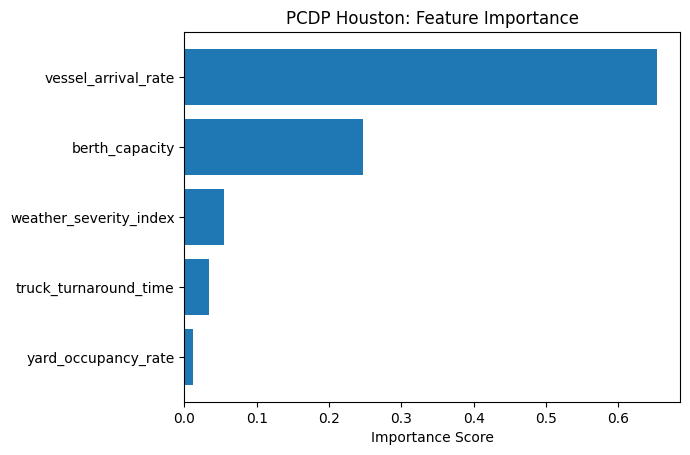

                  Feature  Importance
2     yard_occupancy_rate    0.012374
3   truck_turnaround_time    0.033456
4  weather_severity_index    0.054038
1          berth_capacity    0.246961
0     vessel_arrival_rate    0.653171


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importance values
importances = model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

# Sort by importance (VERY IMPORTANT)
importance_df = importance_df.sort_values("Importance", ascending=True)

# Plot clean horizontal bar chart
plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance Score")
plt.title("PCDP Houston: Feature Importance")
plt.show()

# Also print table for clarity
print(importance_df)


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("houston_pcdp_data.csv")
X = df.drop("delay_hours", axis=1)

baseline_pred = model.predict(X)
baseline_avg = np.mean(baseline_pred)

df_spike = df.copy()
df_spike["vessel_arrival_rate"] = df_spike["vessel_arrival_rate"] * 1.27
X_spike = df_spike.drop("delay_hours", axis=1)

spike_pred = model.predict(X_spike)
spike_avg = np.mean(spike_pred)

print("Baseline Avg Delay (hours):", round(baseline_avg, 2))
print("After 27% Spike Avg Delay (hours):", round(spike_avg, 2))
print("Increase (hours):", round(spike_avg - baseline_avg, 2))


Baseline Avg Delay (hours): 30.16
After 27% Spike Avg Delay (hours): 38.39
Increase (hours): 8.23


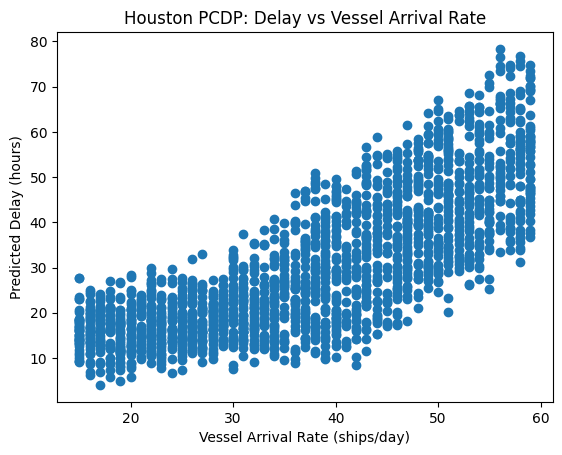

In [5]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values("vessel_arrival_rate")
X_sorted = df_sorted.drop("delay_hours", axis=1)

pred_delay = model.predict(X_sorted)

plt.figure()
plt.scatter(df_sorted["vessel_arrival_rate"], pred_delay)
plt.xlabel("Vessel Arrival Rate (ships/day)")
plt.ylabel("Predicted Delay (hours)")
plt.title("Houston PCDP: Delay vs Vessel Arrival Rate")
plt.show()


In [6]:
# Example: Predict delay for a specific Houston scenario

sample = pd.DataFrame([{
    "vessel_arrival_rate": 55,
    "berth_capacity": 35,
    "yard_occupancy_rate": 80,
    "truck_turnaround_time": 3.5,
    "weather_severity_index": 4
}])

predicted_delay = model.predict(sample)[0]

print("Predicted delay (hours):", round(predicted_delay, 2))


Predicted delay (hours): 46.51


In [7]:
import pandas as pd

def pcdp_predict():
    print("🚢 PCDP Notebook Interface (Houston)")
    print("-" * 45)

    try:
        vessel_arrival_rate = float(input("Vessel arrival rate (ships/day) [15–80]: "))
        berth_capacity = float(input("Berth capacity (active berths) [20–60]: "))
        yard_occupancy_rate = float(input("Yard occupancy rate (%) [40–100]: "))
        truck_turnaround_time = float(input("Truck turnaround time (hours) [0.5–6]: "))
        weather_severity_index = float(input("Weather severity index (0–10): "))
    except ValueError:
        print("❌ Invalid input. Please enter numbers only.")
        return

    # Basic sanity checks
    if not (15 <= vessel_arrival_rate <= 80):
        print("⚠️ Vessel arrival rate is outside the suggested range.")
    if not (20 <= berth_capacity <= 60):
        print("⚠️ Berth capacity is outside the suggested range.")
    if not (40 <= yard_occupancy_rate <= 100):
        print("⚠️ Yard occupancy is outside the suggested range.")
    if not (0.5 <= truck_turnaround_time <= 6):
        print("⚠️ Truck turnaround time is outside the suggested range.")
    if not (0 <= weather_severity_index <= 10):
        print("⚠️ Weather severity is outside the suggested range.")

    sample = pd.DataFrame([{
        "vessel_arrival_rate": vessel_arrival_rate,
        "berth_capacity": berth_capacity,
        "yard_occupancy_rate": yard_occupancy_rate,
        "truck_turnaround_time": truck_turnaround_time,
        "weather_severity_index": weather_severity_index
    }])

    predicted_delay = model.predict(sample)[0]

    # Risk band (simple but useful)
    if predicted_delay < 20:
        risk = "LOW ✅"
    elif predicted_delay < 35:
        risk = "MEDIUM ⚠️"
    else:
        risk = "HIGH 🔴"

    print("\n📌 Results")
    print("-" * 45)
    print(f"Predicted delay (hours): {predicted_delay:.2f}")
    print(f"Risk level: {risk}")

# Run the interface
pcdp_predict()


🚢 PCDP Notebook Interface (Houston)
---------------------------------------------
Vessel arrival rate (ships/day) [15–80]: 70
Berth capacity (active berths) [20–60]: 55
Yard occupancy rate (%) [40–100]: 70
Truck turnaround time (hours) [0.5–6]: 4
Weather severity index (0–10): 5

📌 Results
---------------------------------------------
Predicted delay (hours): 43.04
Risk level: HIGH 🔴


In [8]:
import pandas as pd

def predict_delay_from_inputs(vessel_arrival_rate, berth_capacity, yard_occupancy_rate,
                              truck_turnaround_time, weather_severity_index):
    sample = pd.DataFrame([{
        "vessel_arrival_rate": vessel_arrival_rate,
        "berth_capacity": berth_capacity,
        "yard_occupancy_rate": yard_occupancy_rate,
        "truck_turnaround_time": truck_turnaround_time,
        "weather_severity_index": weather_severity_index
    }])
    return float(model.predict(sample)[0])

def risk_label(delay_hours):
    if delay_hours < 20:
        return "LOW ✅"
    elif delay_hours < 35:
        return "MEDIUM ⚠️"
    return "HIGH 🔴"

def pcdp_compare_scenarios():
    print("🚢 PCDP Scenario Comparison (Houston)")
    print("-" * 55)

    try:
        vessel_arrival_rate = float(input("Baseline vessel arrival rate (ships/day): "))
        berth_capacity = float(input("Baseline berth capacity (active berths): "))
        yard_occupancy_rate = float(input("Baseline yard occupancy rate (%): "))
        truck_turnaround_time = float(input("Baseline truck turnaround time (hours): "))
        weather_severity_index = float(input("Baseline weather severity (0–10): "))
    except ValueError:
        print("❌ Invalid input. Please enter numbers only.")
        return

    # Scenario 1: Baseline
    delay_base = predict_delay_from_inputs(
        vessel_arrival_rate, berth_capacity, yard_occupancy_rate,
        truck_turnaround_time, weather_severity_index
    )

    # Scenario 2: +27% Traffic Spike
    delay_spike = predict_delay_from_inputs(
        vessel_arrival_rate * 1.27, berth_capacity, yard_occupancy_rate,
        truck_turnaround_time, weather_severity_index
    )

    # Scenario 3: Severe Weather (force weather to at least 9.0)
    severe_weather = max(weather_severity_index, 9.0)
    delay_weather = predict_delay_from_inputs(
        vessel_arrival_rate, berth_capacity, yard_occupancy_rate,
        truck_turnaround_time, severe_weather
    )

    # Present results as a table
    results = pd.DataFrame([
        {
            "Scenario": "Baseline",
            "vessel_arrival_rate": vessel_arrival_rate,
            "weather": weather_severity_index,
            "predicted_delay_hours": round(delay_base, 2),
            "risk": risk_label(delay_base)
        },
        {
            "Scenario": "+27% Traffic Spike",
            "vessel_arrival_rate": round(vessel_arrival_rate * 1.27, 2),
            "weather": weather_severity_index,
            "predicted_delay_hours": round(delay_spike, 2),
            "risk": risk_label(delay_spike)
        },
        {
            "Scenario": "Severe Weather",
            "vessel_arrival_rate": vessel_arrival_rate,
            "weather": severe_weather,
            "predicted_delay_hours": round(delay_weather, 2),
            "risk": risk_label(delay_weather)
        }
    ])

    print("\n📊 Scenario Results")
    print("-" * 55)
    print(results.to_string(index=False))

    print("\n🔎 Changes vs Baseline")
    print("-" * 55)
    print(f"Traffic Spike increase: {delay_spike - delay_base:.2f} hours")
    print(f"Severe Weather increase: {delay_weather - delay_base:.2f} hours")

# Run it
pcdp_compare_scenarios()


🚢 PCDP Scenario Comparison (Houston)
-------------------------------------------------------
Baseline vessel arrival rate (ships/day): 66
Baseline berth capacity (active berths): 60
Baseline yard occupancy rate (%): 50
Baseline truck turnaround time (hours): 4
Baseline weather severity (0–10): 7

📊 Scenario Results
-------------------------------------------------------
          Scenario  vessel_arrival_rate  weather  predicted_delay_hours   risk
          Baseline                66.00      7.0                  44.03 HIGH 🔴
+27% Traffic Spike                83.82      7.0                  44.03 HIGH 🔴
    Severe Weather                66.00      9.0                  44.31 HIGH 🔴

🔎 Changes vs Baseline
-------------------------------------------------------
Traffic Spike increase: 0.00 hours
Severe Weather increase: 0.29 hours
